In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import ipywidgets as widgets
from IPython.display import display, clear_output
import shutil

# Configuration
DATASET_PATH = '../datasets'
METADATA_CSV = '../metadata.csv'
OUTPUT_CSV = '../product_views.csv'

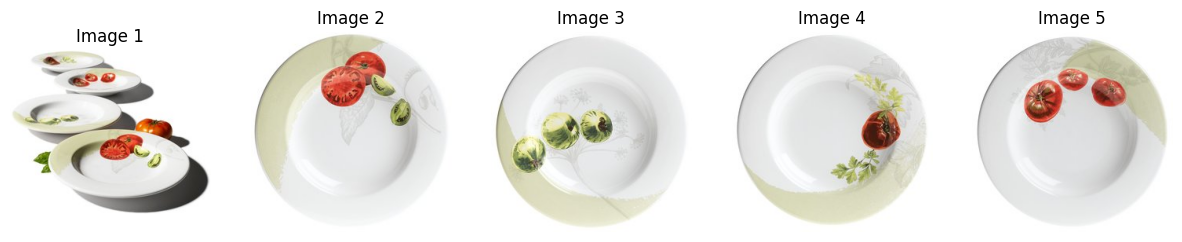

Dropdown(description='Category:', options=('furniture', 'electronics', 'kitchen', 'office', 'other'), value='f…

Dropdown(description='Front:', options=(('None', None), ('Image 1', '../data/small/ff/ff64095c.jpg'), ('Image …

Dropdown(description='Back:', options=(('None', None), ('Image 1', '../data/small/ff/ff64095c.jpg'), ('Image 2…

Dropdown(description='Top:', options=(('None', None), ('Image 1', '../data/small/ff/ff64095c.jpg'), ('Image 2'…

HTML(value='Progress: 132/52401 products processed')

In [ ]:
class ProductViewCategorizer:
    def __init__(self):
        self.dataset = pd.read_csv(METADATA_CSV)
        self.current_index = 0
        self.current_product = None
        self.views_data = []
        
        # Create datasets directory if it doesn't exist
        os.makedirs(DATASET_PATH, exist_ok=True)
        
        # Load existing progress if any
        if os.path.exists(OUTPUT_CSV):
            self.views_data = pd.read_csv(OUTPUT_CSV).to_dict('records')
            self.current_index = len(self.views_data)
        
        # Create UI elements
        self.setup_ui()
    
    def setup_ui(self):
        # Category dropdown
        self.category_dropdown = widgets.Dropdown(
            options=['furniture', 'electronics', 'kitchen', 'office', 'other'],
            description='Category:',
            disabled=False,
        )
        
        # View selection dropdowns
        self.view_dropdowns = {}
        for view in ['front', 'back', 'top']:
            self.view_dropdowns[view] = widgets.Dropdown(
                options=[('None', None)],
                description=f'{view.capitalize()}:',
                disabled=False
            )
        
        # Buttons
        self.save_button = widgets.Button(description='Save Views')
        self.save_button.on_click(self.save_views)
        
        self.skip_button = widgets.Button(description='Skip Product')
        self.skip_button.on_click(self.next_product)
        
        # Progress indicator
        self.progress_text = widgets.HTML()
        self.update_progress()
    
    def update_progress(self):
        total = len(self.dataset)
        self.progress_text.value = f'Progress: {self.current_index}/{total} products processed'
    
    def get_valid_images(self, product):
        """Get list of valid image paths and filter invalid ones"""
        images = []
        try:
            if isinstance(product['main_image'], str):
                images.append(product['main_image'])
            
            if isinstance(product['other_images'], str):
                other_images = product['other_images'].split('|')
                images.extend([img for img in other_images if isinstance(img, str) and pd.notna(img)])
            
            # Filter only existing images
            valid_images = []
            for img_path in images:
                try:
                    # Try opening the image to verify it's valid
                    with Image.open(img_path) as img:
                        valid_images.append(img_path)
                except:
                    continue
            
            return valid_images
        except:
            return []
    
    def display_product_images(self):
        try:
            clear_output(wait=True)
            
            if self.current_index >= len(self.dataset):
                print("All products have been processed!")
                return
            
            self.current_product = self.dataset.iloc[self.current_index]
            
            # Get valid images
            images = self.get_valid_images(self.current_product)
            
            # Skip if less than 3 valid images
            if len(images) < 3:
                print(f"Skipping product {self.current_index} - insufficient valid images")
                self.next_product(None)
                return
            
            # Update dropdown options
            options = [('None', None)] + [(f'Image {i+1}', path) for i, path in enumerate(images)]
            for dropdown in self.view_dropdowns.values():
                dropdown.options = options
            
            # Display images
            plt.figure(figsize=(15, 5))
            for i, image_path in enumerate(images):
                try:
                    plt.subplot(1, len(images), i+1)
                    img = Image.open(image_path)
                    plt.imshow(img)
                    plt.title(f'Image {i+1}')
                    plt.axis('off')
                except Exception as e:
                    print(f"Error displaying image {i+1}")
                    continue
            plt.show()
            
            # Display UI elements
            display(self.category_dropdown)
            for dropdown in self.view_dropdowns.values():
                display(dropdown)
            display(widgets.HBox([self.save_button, self.skip_button]))
            display(self.progress_text)
            self.update_progress()
            
        except Exception as e:
            print(f"Error processing product {self.current_index}")
            self.next_product(None)
    
    def save_views(self, _):
        try:
            # Create product directory
            product_dir = os.path.join(DATASET_PATH, f'product_{self.current_index}')
            os.makedirs(product_dir, exist_ok=True)
            
            # Copy selected images
            view_paths = {}
            for view, dropdown in self.view_dropdowns.items():
                if dropdown.value:
                    try:
                        # Get file extension
                        _, ext = os.path.splitext(dropdown.value)
                        dest_path = os.path.join(product_dir, f'{view}{ext}')
                        
                        # Copy file
                        shutil.copy2(dropdown.value, dest_path)
                        view_paths[f'{view}_path'] = dest_path
                    except:
                        view_paths[f'{view}_path'] = None
                else:
                    view_paths[f'{view}_path'] = None
            
            # Save metadata
            self.views_data.append({
                'product_id': self.current_product['product_id'],
                'category': self.category_dropdown.value,
                **view_paths
            })
            
            # Save to CSV
            pd.DataFrame(self.views_data).to_csv(OUTPUT_CSV, index=False)
            
        except Exception as e:
            print(f"Error saving views for product {self.current_index}")
        
        # Move to next product
        self.next_product(None)
    
    def next_product(self, _):
        self.current_index += 1
        self.display_product_images()

# Create and start the categorizer
categorizer = ProductViewCategorizer()
categorizer.display_product_images()